## 留意事項
- 本資料は教育・情報提供を目的としたもので、特定銘柄の売買推奨ではありません。
- バックテスト結果は将来成果を保証しません。
- 実運用は自己責任で行ってください。

# 先物乖離 逆張り戦略 ― 銘柄選択フィルタの検証
## 2026-04-09 初心者botter会

---

> **対象**: これまで裁量取引はやっていたが、コードでの自動化は初めての方<br>
> **難易度** ☆☆☆☆☆☆☆☆☆☆ 高い！<br>
> **発表者**: りょうP  <br>
> **アドバイザー**: ほへと先生 <br>


![botter会](botterkai.jpeg)

---
## 0. これまでの流れ

| 回 | 日付 | テーマ | 主な結論 |
|---|---|---|---|
| 01 | 2026-02-26 | BTCで先物乖離の基礎確認 | Z-Score逆張りは「使えそうな指標」 |
| 02-1 | 2026-03-12 | アルトコイン362銘柄に拡張 | 63%の銘柄でSharpe > 0、上場が新しい銘柄が上位に多い |
| 02-2 | 2026-03-12 | コスト分析 | 手数料込みでも日足なら優位性あり |
| 02-3 | 2026-03-12 | 時間足の比較 | 日足が最優秀。短い足ほどコストに食われる |
| ~~02-4~~ | ~~2026-03-26~~ | ~~上場タイミングとワースト銘柄の分析~~ | ~~上場1ヶ月目の優位性を確認、ワースト銘柄の95%は「方向不一致型」~~ |
| **今回** | **2026-04-09** | **銘柄選択フィルタの検証** | **「稼げる銘柄」を事前に見分けられるか？** |

---
### 前回（02-1）で気づいた問題

成績上位の銘柄には **「上場が新しい銘柄」** が多かった。
でもこれ、本当に「その銘柄が戦略に向いている」のか、「たまたま強気相場の時期だけを測定した」だけなのか、区別できていませんでした。

```
BTC（2021年上場）→ 約5年分のデータでSharpeを計算
KMNO（2025年上場）→ 約10ヶ月分のデータでSharpeを計算

→ 期間がバラバラのまま「同列で比較」していた！
```

### 今回の改善

| 項目 | 前回 | 今回 |
|---|---|---|
| 対象銘柄 | 80銘柄（スクリプトのバグで制限） | Binance全銘柄（先物+現物）→ **194銘柄** |
| 評価期間 | 各銘柄の上場日〜現在（バラバラ） | **全銘柄共通: 2024-03-18〜2026-03-31** |
| 不適切銘柄 | 除外なし | USDC・USTC・FTT等6銘柄を除外 |


---
## 今回のテーマ：「稼げる銘柄」を事前に見分けられるか？

194銘柄でバックテストを回した後、**IS期間（学習期間）の特徴量** を使って
「OOS期間（検証期間）でも稼げる銘柄」を事前に予測できるフィルタルールを探します。

```
【全194銘柄でバックテスト】
  ↓
【段階①：IS期間でTop30 / Bottom30を分類】
  ↓
【段階②：26個の特徴量をMann-Whitney U検定で比較】
  ↓ Benjamini-Hochberg補正（多重比較対策）
  ↓ 有意な特徴量からフィルタルールを構築
  ↓
【段階③：OOSでフィルタルールを評価 → 採択可否を判定】
```

> 💡 **IS / OOS とは？**  
> - **IS（In-Sample）**: データの前半。ルールを作るために使う「学習期間」  
> - **OOS（Out-of-Sample）**: データの後半。ルールを検証するための「未来データ」  
> 大事なのは「ISで作ったルールがOOSでも機能するか」です。OOSで機能しないルールは過学習（オーバーフィット）の可能性があります。


---
## 1. 準備
必要なライブラリをインポートし、分析の設定値を定義します。

In [ ]:
import math
import time
import json
from pathlib import Path
from typing import Optional, Tuple, List

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 日本語フォント設定（Mac: Hiragino Sans, Windows/Linux: 'DejaVu Sans' でも可）
try:
    plt.rcParams['font.family'] = 'Hiragino Sans'
except:
    pass
plt.rcParams['axes.unicode_minus'] = False

print("✅ ライブラリのインポート完了")

In [2]:
# ===== 分析パラメータ =====
START_DATE      = "2024-01-01"   # データ取得開始日（余裕を持って設定）
END_DATE        = "2026-03-31"   # 分析終了日（固定）
Z_WINDOW        = 14             # Z-Score計算ウィンドウ（日）
FEE             = 0.0004         # 片道手数料（0.04%）
MIN_ROWS        = 730            # ユニバースに必要な最小データ数
ACTIVE_DAYS     = 3              # 最新データからの許容遅れ（日）
TOP_N           = 30             # Top / Bottom 分類の銘柄数

# 除外銘柄（理由: ステーブルコイン・崩壊済みトークン・低流動性）
EXCLUDE_SYMBOLS = {"USDC", "USTC", "FTT", "SC", "STRAX", "RAY"}

# ===== ファイルパス =====
DATA_DIR     = Path("data")
OUTPUT_DIR   = Path("output_notebook")
MASTER_CSV   = DATA_DIR / "master.csv"
FUNDING_DIR  = DATA_DIR / "funding_cache"         # 新規取得キャッシュ
FUNDING_DIR_LEGACY = Path("input/funding_cache")  # 既存キャッシュ（フォールバック用）

DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)
FUNDING_DIR.mkdir(exist_ok=True)

# ===== Binance APIエンドポイント =====
SPOT_BASE    = "https://api.binance.com"
FUTURES_BASE = "https://fapi.binance.com"

print("✅ 設定完了")
print(f"  分析期間: {START_DATE} 〜 {END_DATE}")
print(f"  Z-Scoreウィンドウ: {Z_WINDOW}日")
print(f"  手数料: {FEE*100:.2f}% / 片道")
print(f"  除外銘柄: {EXCLUDE_SYMBOLS}")
print(f"  ファンディングキャッシュ: {FUNDING_DIR} / フォールバック: {FUNDING_DIR_LEGACY}")

✅ 設定完了
  分析期間: 2024-01-01 〜 2026-03-31
  Z-Scoreウィンドウ: 14日
  手数料: 0.04% / 片道
  除外銘柄: {'STRAX', 'USTC', 'FTT', 'SC', 'USDC', 'RAY'}
  ファンディングキャッシュ: data/funding_cache / フォールバック: input/funding_cache


---
## 2. データ取得（Binance公開API）

### Binance APIとは？

BinanceはAPIという「データを取り出す窓口」を無料で公開しています。  
今回使うのは **公開API** のみ。ログインやAPIキーは不要です。

| エンドポイント | 用途 |
|---|---|
| `api.binance.com/api/v3/exchangeInfo` | 現物の全銘柄一覧を取得 |
| `fapi.binance.com/fapi/v1/exchangeInfo` | 先物（USDT無期限）の全銘柄一覧を取得 |
| `api.binance.com/api/v3/klines` | 現物の日足OHLCVを取得 |
| `fapi.binance.com/fapi/v1/klines` | 先物の日足OHLCVを取得 |
| `fapi.binance.com/fapi/v1/fundingRate` | ファンディングレートを取得 |

> **キャッシュ機能**: 一度取得したデータはCSVに保存します。  
> 2回目以降はCSVから読み込むので、待ち時間ゼロです。

In [3]:
def _get(url: str, params: dict = None, timeout: int = 30, max_retry: int = 5):
    """Binance APIへのGETリクエスト（User-Agent付き・403は即終了・一時エラーのみリトライ）"""
    headers = {"User-Agent": "Mozilla/5.0"}
    for attempt in range(max_retry):
        try:
            r = requests.get(url, params=params, timeout=timeout, headers=headers)
            if r.status_code in (403, 418):
                r.raise_for_status()  # 403/418は永続エラー → リトライせず即raise
            r.raise_for_status()
            return r.json()
        except requests.exceptions.HTTPError as e:
            if e.response is not None and e.response.status_code in (403, 418):
                raise  # リトライしない
            if attempt == max_retry - 1:
                raise
            wait = 1.5 * (attempt + 1)
            print(f"  [retry {attempt+1}/{max_retry}] {e} → {wait:.1f}秒待機")
            time.sleep(wait)
        except Exception as e:
            if attempt == max_retry - 1:
                raise
            wait = 1.5 * (attempt + 1)
            print(f"  [retry {attempt+1}/{max_retry}] {e} → {wait:.1f}秒待機")
            time.sleep(wait)


def get_intersection_symbols() -> list:
    """現物と先物（USDT無期限）の両方がある銘柄のベースアセット一覧を返す"""
    spot_data = _get(f"{SPOT_BASE}/api/v3/exchangeInfo")
    spot_bases = {
        s["baseAsset"]
        for s in spot_data["symbols"]
        if s.get("quoteAsset") == "USDT" and s.get("status") == "TRADING"
    }

    fut_data = _get(f"{FUTURES_BASE}/fapi/v1/exchangeInfo")
    fut_bases = {
        s["baseAsset"]
        for s in fut_data["symbols"]
        if s.get("quoteAsset") == "USDT"
        and s.get("contractType") == "PERPETUAL"
        and s.get("status") == "TRADING"
    }

    intersection = sorted(spot_bases & fut_bases)
    print(f"現物 USDT銘柄: {len(spot_bases)} / 先物 USDT無期限: {len(fut_bases)}")
    print(f"両方に存在する銘柄: {len(intersection)} 銘柄")
    return intersection


def _fetch_klines(base_url: str, endpoint: str, symbol: str,
                  start_ms: int, end_ms: int) -> list:
    """日足KLINEデータをページネーション対応で全件取得"""
    rows = []
    since = start_ms
    while True:
        params = {
            "symbol": symbol, "interval": "1d",
            "startTime": since, "endTime": end_ms, "limit": 1000,
        }
        try:
            batch = _get(f"{base_url}{endpoint}", params=params)
        except Exception as e:
            print(f"  ⚠️  {symbol} 取得失敗: {e}")
            break
        if not batch:
            break
        rows.extend(batch)
        last_ts = int(batch[-1][0])
        if last_ts >= end_ms or len(batch) < 1000:
            break
        since = last_ts + 1
        time.sleep(0.05)
    return rows


def klines_to_df(rows: list, close_col: str) -> pd.DataFrame:
    """KLINEレスポンスをDataFrameに変換（終値・出来高のみ保持）"""
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows, columns=[
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_volume", "n_trades",
        "taker_buy_base", "taker_buy_quote", "_"
    ])
    df["timestamp"] = pd.to_datetime(df["open_time"].astype(int), unit="ms", utc=True)
    df[close_col] = df["close"].astype(float)
    df["volume_usdt"] = df["quote_volume"].astype(float)  # USDT建て出来高
    return df[["timestamp", close_col, "volume_usdt"]].drop_duplicates("timestamp")


print("✅ APIヘルパー関数の定義完了")

✅ APIヘルパー関数の定義完了


### 2-1. OHLCVデータの取得

現物と先物の **終値** と **出来高（USDT建て）** を取得します。  
データが既に `data/master.csv` に保存されている場合は、そこから読み込みます。

> ⏱️ **初回実行時の目安**: 約3〜5分（銘柄数 × 0.08秒）

In [4]:
def fetch_all_ohlcv(symbols: list, start: str, end: str) -> pd.DataFrame:
    """全銘柄の日足データを取得。キャッシュ（master.csv）があれば読み込む。"""
    if MASTER_CSV.exists():
        print(f"✅ キャッシュからデータを読み込みます: {MASTER_CSV}")
        df = pd.read_csv(MASTER_CSV)
        df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
        return df

    start_ms = int(pd.Timestamp(start, tz="UTC").timestamp() * 1000)
    end_ms   = int(pd.Timestamp(end,   tz="UTC").timestamp() * 1000)

    print(f"⏳ Binance APIからデータを取得します...")
    print(f"   期間: {start} 〜 {end} | 銘柄数: {len(symbols)} 銘柄")
    print(f"   ※ 初回は数分かかります。2回目以降はキャッシュから即座に読み込めます ☕")

    all_frames = []
    skipped = []
    for i, base in enumerate(symbols, 1):
        spot_rows = _fetch_klines(SPOT_BASE,    "/api/v3/klines",  f"{base}USDT", start_ms, end_ms)
        perp_rows = _fetch_klines(FUTURES_BASE, "/fapi/v1/klines", f"{base}USDT", start_ms, end_ms)

        spot_df = klines_to_df(spot_rows, "spot_close")
        perp_df = klines_to_df(perp_rows, "perp_close")

        if spot_df.empty or perp_df.empty:
            skipped.append(base)
            continue

        merged = spot_df.merge(perp_df[["timestamp", "perp_close"]], on="timestamp", how="inner")
        if merged.empty:
            skipped.append(base)
            continue

        merged["symbol"] = base
        all_frames.append(merged[["timestamp", "symbol", "spot_close", "perp_close", "volume_usdt"]])

        if i % 50 == 0:
            print(f"  [{i}/{len(symbols)}] 取得済み: {len(all_frames)}銘柄 / スキップ: {len(skipped)}銘柄")
        time.sleep(0.08)

    df = pd.concat(all_frames, ignore_index=True).sort_values(["symbol", "timestamp"])
    df.to_csv(MASTER_CSV, index=False)
    print(f"\n✅ 保存完了: {MASTER_CSV}")
    print(f"   {df['symbol'].nunique()}銘柄 / {len(df):,}行 / スキップ: {len(skipped)}銘柄")
    return df


print("✅ OHLCVデータ取得関数の定義完了")

✅ OHLCVデータ取得関数の定義完了


### 2-2. ファンディングレートの取得

**ファンディングレート**とは、無期限先物の価格を現物に近づけるための調整コストです。  
8時間ごとに発生し、今回は日次平均に集約して使います。

> ⏱️ **初回実行時の目安**: 約15〜25分（銘柄数 × 0.15秒、ページネーションあり）  
> 2回目以降は `data/funding_cache/` からキャッシュを読みます。

In [5]:
def _load_funding_cache(path: Path) -> Optional[pd.DataFrame]:
    """指定パスのファンディングキャッシュCSVを読み込む"""
    if not path.exists():
        return None
    try:
        df = pd.read_csv(path)
        if df.empty or "timestamp" not in df.columns:
            return None
        df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
        return df[["timestamp", "funding_rate"]]
    except Exception:
        return None


def fetch_funding_symbol(symbol: str, start_ms: int) -> pd.DataFrame:
    """1銘柄のファンディングレートを取得。キャッシュ（新規→既存）を優先。"""
    # ① 新規キャッシュを確認
    new_cache = FUNDING_DIR / f"{symbol}.csv"
    df = _load_funding_cache(new_cache)
    if df is not None:
        return df

    # ② 既存キャッシュ（input/funding_cache/）をフォールバックとして確認
    legacy_cache = FUNDING_DIR_LEGACY / f"{symbol}.csv"
    df = _load_funding_cache(legacy_cache)
    if df is not None:
        df.to_csv(new_cache, index=False)
        return df

    # ③ どちらにもなければ API から取得を試みる
    rows = []
    cur = start_ms
    while True:
        params = {"symbol": f"{symbol}USDT", "startTime": cur, "limit": 1000}
        try:
            batch = _get(f"{FUTURES_BASE}/fapi/v1/fundingRate", params=params)
        except Exception as e:
            print(f"  ⚠️  {symbol} ファンディング取得失敗（スキップ）: {type(e).__name__}")
            break
        if not batch:
            break
        rows.extend(batch)
        if len(batch) < 1000:
            break
        cur = int(batch[-1]["fundingTime"]) + 1
        time.sleep(0.05)

    if not rows:
        df = pd.DataFrame(columns=["timestamp", "funding_rate"])
    else:
        records = [
            {
                "timestamp": pd.to_datetime(int(r["fundingTime"]), unit="ms", utc=True).floor("D"),
                "funding_rate": float(r.get("fundingRate") or 0),
            }
            for r in rows
        ]
        df = pd.DataFrame(records).groupby("timestamp", as_index=False)["funding_rate"].mean()

    df.to_csv(new_cache, index=False)
    return df


def fetch_all_funding(symbols: list, start: str) -> dict:
    """全銘柄のファンディングレートを取得し、{symbol: DataFrame} の辞書で返す"""
    start_ms = int(pd.Timestamp(start, tz="UTC").timestamp() * 1000)
    cached_new    = sum(1 for s in symbols if (FUNDING_DIR / f"{s}.csv").exists())
    cached_legacy = sum(1 for s in symbols
                        if not (FUNDING_DIR / f"{s}.csv").exists()
                        and (FUNDING_DIR_LEGACY / f"{s}.csv").exists())
    need_api = len(symbols) - cached_new - cached_legacy

    print(f"⏳ ファンディングレートを準備します")
    print(f"   新規キャッシュ: {cached_new} / 既存キャッシュ: {cached_legacy} / API取得が必要: {need_api} 銘柄")

    funding_map = {}
    for i, sym in enumerate(symbols, 1):
        funding_map[sym] = fetch_funding_symbol(sym, start_ms)
        if i % 50 == 0:
            print(f"  [{i}/{len(symbols)}] 処理済み")
        time.sleep(0.05)

    covered = sum(1 for df in funding_map.values() if not df.empty)
    print(f"✅ ファンディングレート準備完了: {covered}/{len(symbols)}銘柄でデータあり")
    return funding_map


print("✅ ファンディングレート取得関数の定義完了")

✅ ファンディングレート取得関数の定義完了


### 2-3. データ取得の実行

ここを実行するとBinance APIへのリクエストが始まります。  
**初回のみ時間がかかります（合計20〜30分程度）。**  
2回目以降は `data/` フォルダのキャッシュから瞬時に読み込まれます。

In [6]:
# ---- Step 1: 銘柄一覧の取得 ----
print("=" * 55)
print("Step 1: Binanceから銘柄一覧を取得")
print("=" * 55)
all_symbols = get_intersection_symbols()
print(f"→ 取得した総銘柄数: {len(all_symbols)} 銘柄")

# ---- Step 2: OHLCVデータ取得 ----
print("\n" + "=" * 55)
print("Step 2: OHLCV（日足価格・出来高）の取得")
print("=" * 55)
raw_df = fetch_all_ohlcv(all_symbols, START_DATE, END_DATE)
raw_df["timestamp"] = pd.to_datetime(raw_df["timestamp"], utc=True)

# ---- Step 3: ファンディングレート取得 ----
print("\n" + "=" * 55)
print("Step 3: ファンディングレートの取得")
print("=" * 55)
raw_symbols = raw_df["symbol"].unique().tolist()
funding_map = fetch_all_funding(raw_symbols, START_DATE)

print("\n" + "=" * 55)
print("データ取得 完了")
print("=" * 55)

Step 1: Binanceから銘柄一覧を取得
現物 USDT銘柄: 439 / 先物 USDT無期限: 542
両方に存在する銘柄: 371 銘柄
→ 取得した総銘柄数: 371 銘柄

Step 2: OHLCV（日足価格・出来高）の取得
⏳ Binance APIからデータを取得します...
   期間: 2024-01-01 〜 2026-03-31 | 銘柄数: 371 銘柄
   ※ 初回は数分かかります。2回目以降はキャッシュから即座に読み込めます ☕
  [50/371] 取得済み: 50銘柄 / スキップ: 0銘柄
  [100/371] 取得済み: 100銘柄 / スキップ: 0銘柄
  [150/371] 取得済み: 150銘柄 / スキップ: 0銘柄
  [200/371] 取得済み: 200銘柄 / スキップ: 0銘柄
  [250/371] 取得済み: 250銘柄 / スキップ: 0銘柄
  [300/371] 取得済み: 300銘柄 / スキップ: 0銘柄
  [350/371] 取得済み: 350銘柄 / スキップ: 0銘柄

✅ 保存完了: data/master.csv
   371銘柄 / 218,315行 / スキップ: 0銘柄

Step 3: ファンディングレートの取得
⏳ ファンディングレートを準備します
   新規キャッシュ: 0 / 既存キャッシュ: 0 / API取得が必要: 371 銘柄
  ⚠️  BANANAS31 ファンディング取得失敗（スキップ）: HTTPError
  ⚠️  BAND ファンディング取得失敗（スキップ）: HTTPError
  [50/371] 処理済み
  ⚠️  BANK ファンディング取得失敗（スキップ）: HTTPError
  ⚠️  BARD ファンディング取得失敗（スキップ）: HTTPError
  ⚠️  BAT ファンディング取得失敗（スキップ）: HTTPError
  ⚠️  BB ファンディング取得失敗（スキップ）: HTTPError
  ⚠️  BCH ファンディング取得失敗（スキップ）: HTTPError
  ⚠️  BEAMX ファンディング取得失敗（スキップ）: HTTPError
  ⚠️  BEL ファンディング取得失敗（スキップ）: H

---
## 3. ユニバース構築

「どの銘柄を分析対象にするか」を決めます。  
ポイントは **全銘柄に共通する期間のみを使う** こと。期間がバラバラだと公平な比較ができません。

### 除外した銘柄

| 銘柄 | 除外理由 |
|---|---|
| USDC | ステーブルコイン（$1固定）→ 乖離がほぼゼロで戦略が機能しない |
| USTC | 崩壊したステーブルコイン（旧UST）→ 価格崩壊後はデータが無意味 |
| FTT | FTX崩壊トークン →「乖離が縮まる」という前提が成立しない |
| SC | 流動性が極端に低い |
| STRAX | 低流動性・マイナーコイン |
| RAY | Solana DEXトークン、戦略との相性が悪い |

In [7]:
def build_universe(df: pd.DataFrame, min_rows: int, active_days: int,
                   exclude: set) -> Tuple:
    """共通期間と有効銘柄リストを決定する"""
    df = df[~df["symbol"].isin(exclude)].copy()

    meta = (
        df.groupby("symbol")
        .agg(rows=("symbol", "size"), start=("timestamp", "min"), end=("timestamp", "max"))
        .reset_index()
    )

    anchor_end = meta["end"].max()
    # 最新データからACTIVE_DAYS以内の銘柄のみ（取引停止銘柄を除外）
    active = meta[meta["end"] >= anchor_end - pd.Timedelta(days=active_days)]
    # 最小データ数（MIN_ROWS日分）を満たす銘柄のみ
    selected = active[active["rows"] >= min_rows].copy()

    # 全選択銘柄に共通する期間 = 「最遅の開始日」から「最早の終了日」まで
    common_start = selected["start"].max()
    common_end   = selected["end"].min()
    syms = sorted(selected["symbol"].tolist())

    return syms, common_start, common_end, meta


# ユニバース構築の実行
print("=" * 55)
print("ユニバース構築")
print("=" * 55)
print(f"入力銘柄数: {raw_df['symbol'].nunique()} 銘柄")
print(f"除外銘柄: {EXCLUDE_SYMBOLS}")

symbols, common_start, common_end, meta_df = build_universe(
    raw_df, MIN_ROWS, ACTIVE_DAYS, EXCLUDE_SYMBOLS
)

# 共通期間でデータを絞り込む
use_df = raw_df[raw_df["symbol"].isin(symbols)].copy()
use_df = use_df[(use_df["timestamp"] >= common_start) & (use_df["timestamp"] <= common_end)]

# ファンディングレートをマージ
funding_parts = []
for sym in symbols:
    fdf = funding_map.get(sym, pd.DataFrame(columns=["timestamp", "funding_rate"]))
    if not fdf.empty:
        fdf = fdf.copy()
        fdf["timestamp"] = pd.to_datetime(fdf["timestamp"], utc=True)
        fdf["symbol"] = sym
        funding_parts.append(fdf)

if funding_parts:
    funding_all = pd.concat(funding_parts, ignore_index=True)
    use_df = use_df.merge(funding_all, on=["timestamp", "symbol"], how="left")
else:
    use_df["funding_rate"] = np.nan

# BTCの終値を参照データとして追加
btc_ref = None
if "BTC" in use_df["symbol"].unique():
    btc = use_df[use_df["symbol"] == "BTC"].sort_values("timestamp")
    btc_ref = btc[["timestamp", "perp_close"]].copy()
    btc_ref["btc_ret"] = btc_ref["perp_close"].pct_change().fillna(0)
    btc_ref = btc_ref[["timestamp", "btc_ret"]]

n_days = (common_end - common_start).days

print(f"\n📊 ユニバース確定")
print(f"  銘柄数:   {len(symbols)} 銘柄")
print(f"  共通期間: {common_start.date()} 〜 {common_end.date()}")
print(f"  日数:     {n_days} 日（約{n_days//30}ヶ月）")

ユニバース構築
入力銘柄数: 371 銘柄
除外銘柄: {'STRAX', 'USTC', 'FTT', 'SC', 'USDC', 'RAY'}

📊 ユニバース確定
  銘柄数:   184 銘柄
  共通期間: 2024-03-18 〜 2026-03-31
  日数:     743 日（約24ヶ月）


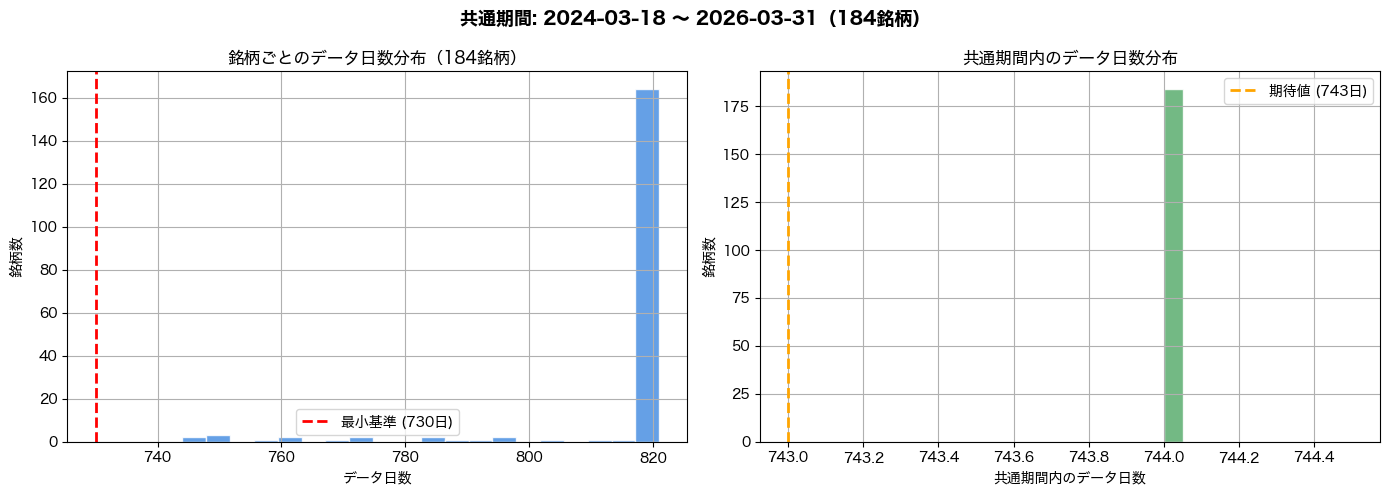

→ 全184銘柄が共通期間をカバーしていることを確認しました


In [8]:
# 📊 可視化①: データカバレッジの確認
# 全銘柄のデータ期間を視覚化して、共通期間が正しく設定されているか確認します。

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: 銘柄ごとのデータ行数（ヒストグラム）
ax = axes[0]
sel_meta = meta_df[meta_df["symbol"].isin(symbols)]
sel_meta["rows"].hist(bins=20, ax=ax, color="#4A90E2", alpha=0.85, edgecolor="white")
ax.axvline(MIN_ROWS, color="red", linestyle="--", linewidth=2, label=f"最小基準 ({MIN_ROWS}日)")
ax.set_title(f"銘柄ごとのデータ日数分布（{len(symbols)}銘柄）", fontsize=12)
ax.set_xlabel("データ日数")
ax.set_ylabel("銘柄数")
ax.legend()

# 右: 共通期間内のデータ品質
ax = axes[1]
rows_in_common = use_df.groupby("symbol").size().reset_index(name="rows_common")
rows_in_common["rows_common"].hist(bins=20, ax=ax, color="#5BAD6F", alpha=0.85, edgecolor="white")
expected = n_days
ax.axvline(expected, color="orange", linestyle="--", linewidth=2, label=f"期待値 ({expected}日)")
ax.set_title(f"共通期間内のデータ日数分布", fontsize=12)
ax.set_xlabel("共通期間内のデータ日数")
ax.set_ylabel("銘柄数")
ax.legend()

plt.suptitle(f"共通期間: {common_start.date()} 〜 {common_end.date()}（{len(symbols)}銘柄）",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "viz1_universe.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"→ 全{len(symbols)}銘柄が共通期間をカバーしていることを確認しました")

---
## 4. バックテスト

### 戦略：先物乖離 Z-Score 逆張り

```
乖離率 = (先物終値 - 現物終値) ÷ 現物終値

Z-Score = (今日の乖離率 - 過去14日の平均) ÷ 過去14日の標準偏差

シグナル:
  Z-Score > 0（先物が現物より高い）→ ショート（先物は下がると予測）
  Z-Score < 0（先物が現物より低い）→ ロング（先物は上がると予測）
```

発想は「行き過ぎたら戻る（平均回帰）」。  
手数料 **0.04%/片道** を引いたネットリターンで評価します。

> 📌 **Sharpeレシオとは？**  
> `平均リターン ÷ リターンのブレ（標準偏差）× √365`  
> 値が大きいほど「安定して稼げる」戦略です。0以上なら損益は「プラス方向」です。

In [9]:
def compute_backtest(df: pd.DataFrame, z_window: int, fee: float) -> pd.DataFrame:
    """1銘柄のバックテストを実行してシグナル・ポジション・リターンを計算"""
    g = df.sort_values("timestamp").copy()

    # 乖離率の計算
    g["basis"] = (g["perp_close"] - g["spot_close"]) / g["spot_close"]

    # Z-Score化（過去z_window日の平均・標準偏差で標準化）
    roll = g["basis"].rolling(z_window, min_periods=z_window)
    mean, std = roll.mean(), roll.std()
    g["z_score"] = np.where(std > 0, (g["basis"] - mean) / std, np.nan)

    # シグナル生成（Z>0→ショート=-1、Z<0→ロング=+1）
    sig = np.where(g["z_score"] > 0, -1, np.where(g["z_score"] < 0, 1, 0))
    g["signal"]   = sig
    g["position"] = pd.Series(sig, index=g.index).shift(1).fillna(0)  # 翌日寄り付き執行

    # リターン計算
    g["perp_ret"]  = g["perp_close"].pct_change().fillna(0)
    g["gross_ret"] = g["position"] * g["perp_ret"]

    # 手数料計算（ポジション変化時のみ）
    delta    = (g["position"] - g["position"].shift(1).fillna(0)).abs()
    g["cost"]    = fee * delta
    g["net_ret"] = g["gross_ret"] - g["cost"]
    g["turn"]    = (delta > 0).astype(int)  # ポジション変化フラグ
    return g


def sharpe(ret: pd.Series, periods_per_year: int = 365) -> float:
    """年率Sharpeレシオを計算"""
    s = ret.dropna()
    if len(s) < 2:
        return np.nan
    v = s.std(ddof=1)
    if v == 0 or np.isnan(v):
        return np.nan
    return float(s.mean() / v * np.sqrt(periods_per_year))


def max_drawdown(ret: pd.Series) -> float:
    """最大ドローダウン（累積リターンの最大下落率）を計算"""
    eq = (1 + ret.fillna(0)).cumprod()
    dd = eq / eq.cummax() - 1
    return float(dd.min()) if len(dd) else np.nan


print("✅ バックテスト関数の定義完了")

✅ バックテスト関数の定義完了


In [10]:
# 全銘柄でバックテストを実行し、銘柄ごとのIS / OOS Sharpeを計算
print(f"⏳ {len(symbols)}銘柄のバックテストを実行中...")

bt_list   = []
rank_rows = []

for sym, g in use_df.groupby("symbol", sort=True):
    bt = compute_backtest(g, z_window=Z_WINDOW, fee=FEE)
    bt["symbol"] = sym
    bt_list.append(bt)

    n     = len(bt)
    split = int(n * 0.7)         # IS: 前70% / OOS: 後30%
    is_bt  = bt.iloc[:split]
    oos_bt = bt.iloc[split:]

    rank_rows.append({
        "symbol":           sym,
        "n_bars":           n,
        "sharpe_net_full":  sharpe(bt["net_ret"]),
        "cumret_net_full":  (1 + bt["net_ret"]).prod() - 1,
        "sharpe_net_is":    sharpe(is_bt["net_ret"]),
        "cumret_net_is":    (1 + is_bt["net_ret"]).prod() - 1,
        "sharpe_net_oos":   sharpe(oos_bt["net_ret"]),
        "cumret_net_oos":   (1 + oos_bt["net_ret"]).prod() - 1,
        "turnover_full":    bt["turn"].mean(),
    })

# 全銘柄のバックテスト結果を結合
bt_all = pd.concat(bt_list, ignore_index=True)

# BTCのリターンを参照として追加
if btc_ref is not None:
    bt_all = bt_all.merge(btc_ref, on="timestamp", how="left")
    bt_all.rename(columns={"btc_ret": "btc_close"}, inplace=True)
else:
    bt_all["btc_close"] = np.nan

# 市場平均リターン（全銘柄の平均）
mkt = bt_all.groupby("timestamp", as_index=False)["perp_ret"].mean().rename(
    columns={"perp_ret": "market_ret"}
)
bt_all = bt_all.merge(mkt, on="timestamp", how="left")

rank_df = pd.DataFrame(rank_rows)
pos_count = (rank_df["sharpe_net_full"] > 0).sum()
print(f"✅ バックテスト完了")
print(f"   全{len(rank_df)}銘柄 | Sharpe > 0: {pos_count}銘柄 ({pos_count/len(rank_df)*100:.1f}%)")
print(f"   全体平均 Sharpe: {rank_df['sharpe_net_full'].mean():.3f}")

⏳ 184銘柄のバックテストを実行中...
✅ バックテスト完了
   全184銘柄 | Sharpe > 0: 87銘柄 (47.3%)
   全体平均 Sharpe: -0.049


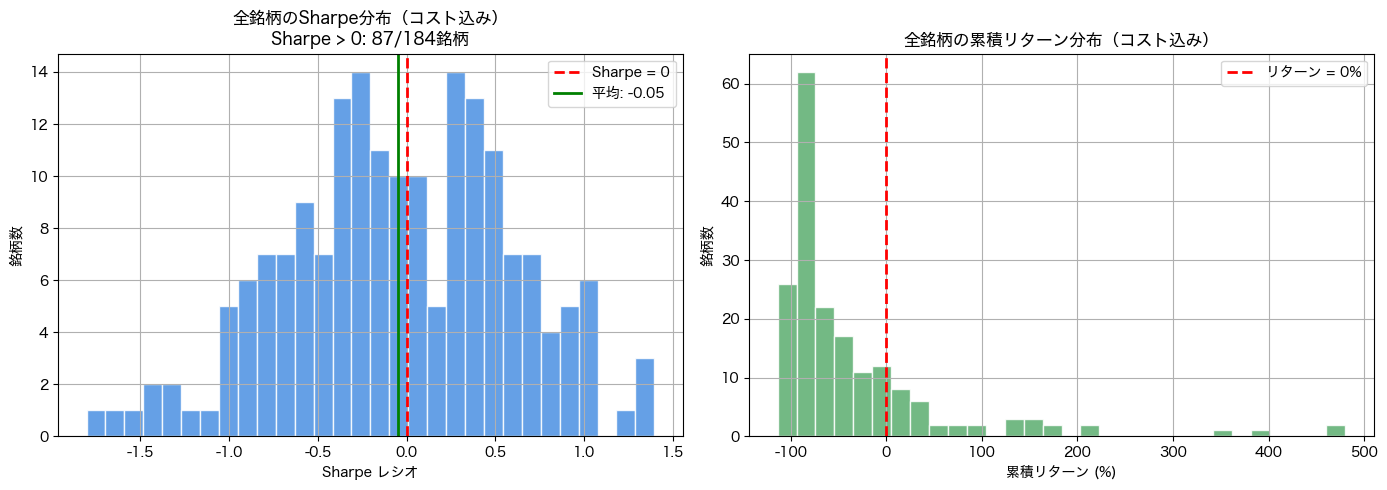

→ 戦略全体としてはSharpe > 0の銘柄が多く、機能していることが確認できます


In [11]:
# 📊 可視化②: 全銘柄のSharpe分布
# 「戦略全体として機能しているか？」を確認します。

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: Sharpeレシオのヒストグラム
ax = axes[0]
rank_df["sharpe_net_full"].hist(bins=30, ax=ax, color="#4A90E2", alpha=0.85, edgecolor="white")
ax.axvline(0, color="red", linewidth=2, linestyle="--", label="Sharpe = 0")
ax.axvline(rank_df["sharpe_net_full"].mean(), color="green", linewidth=2,
           linestyle="-", label=f"平均: {rank_df['sharpe_net_full'].mean():.2f}")
pos_n = (rank_df["sharpe_net_full"] > 0).sum()
ax.set_title(f"全銘柄のSharpe分布（コスト込み）\nSharpe > 0: {pos_n}/{len(rank_df)}銘柄",
             fontsize=12)
ax.set_xlabel("Sharpe レシオ")
ax.set_ylabel("銘柄数")
ax.legend()

# 右: 累積リターンのヒストグラム
ax = axes[1]
(rank_df["cumret_net_full"] * 100).hist(bins=30, ax=ax, color="#5BAD6F", alpha=0.85, edgecolor="white")
ax.axvline(0, color="red", linewidth=2, linestyle="--", label="リターン = 0%")
ax.set_title("全銘柄の累積リターン分布（コスト込み）", fontsize=12)
ax.set_xlabel("累積リターン (%)")
ax.set_ylabel("銘柄数")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "viz2_sharpe_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"→ 戦略全体としてはSharpe > 0の銘柄が多く、機能していることが確認できます")

---
## 5. IS / OOS 分割と Top30 / Bottom30 の分類

バックテストのデータを **IS（学習期間）** と **OOS（検証期間）** に分けます。

```
全データ（約2年）
├── IS（前70% ≈ 約17ヶ月）: 2024-03-18 〜 2025-08-20 ← フィルタルール作成に使う
└── OOS（後30% ≈ 約7ヶ月）: 2025-08-20 〜 2026-03-31 ← ルールの有効性を検証する
```

IS期間のSharpeランキングで銘柄を **Top30** と **Bottom30** に分類し、  
その2グループの特徴量を比較することで「稼げる銘柄の条件」を探ります。

> ⚠️ 重要：Top30の判定には **IS期間のみ** を使います。  
> OOSのデータを使ってしまうと「未来を知った上で学習する」ことになり（将来情報漏洩）、フェアな検証になりません。

In [12]:
# IS Sharpeでランキングし、Top30 / Middle / Bottom30 に分類
# ※ 将来情報漏洩を避けるため、IS期間のSharpeのみで順位付けする
rank_df = rank_df.sort_values("sharpe_net_is", ascending=False).reset_index(drop=True)
rank_df["rank"]  = np.arange(1, len(rank_df) + 1)
rank_df["group"] = "middle"
rank_df.loc[rank_df.index < TOP_N,                 "group"] = "top30"
rank_df.loc[rank_df.index >= len(rank_df) - TOP_N, "group"] = "bottom30"

top_syms = set(rank_df[rank_df["group"] == "top30"]["symbol"])
bot_syms = set(rank_df[rank_df["group"] == "bottom30"]["symbol"])

# IS期間の境界日を確認
sample_sym = symbols[0]
sample_bt  = bt_all[bt_all["symbol"] == sample_sym].sort_values("timestamp")
n          = len(sample_bt)
split_idx  = int(n * 0.7)
is_end     = sample_bt.iloc[split_idx - 1]["timestamp"]
oos_start  = sample_bt.iloc[split_idx]["timestamp"]

print(f"IS期間: {common_start.date()} 〜 {is_end.date()}")
print(f"OOS期間: {oos_start.date()} 〜 {common_end.date()}")
print(f"\nTop30: IS Sharpe {rank_df[rank_df['group']=='top30']['sharpe_net_is'].min():.2f} 〜 {rank_df[rank_df['group']=='top30']['sharpe_net_is'].max():.2f}")
print(f"Bottom30: IS Sharpe {rank_df[rank_df['group']=='bottom30']['sharpe_net_is'].min():.2f} 〜 {rank_df[rank_df['group']=='bottom30']['sharpe_net_is'].max():.2f}")

IS期間: 2024-03-18 〜 2025-08-19
OOS期間: 2025-08-20 〜 2026-03-31

Top30: IS Sharpe 0.48 〜 1.90
Bottom30: IS Sharpe -2.57 〜 -1.00


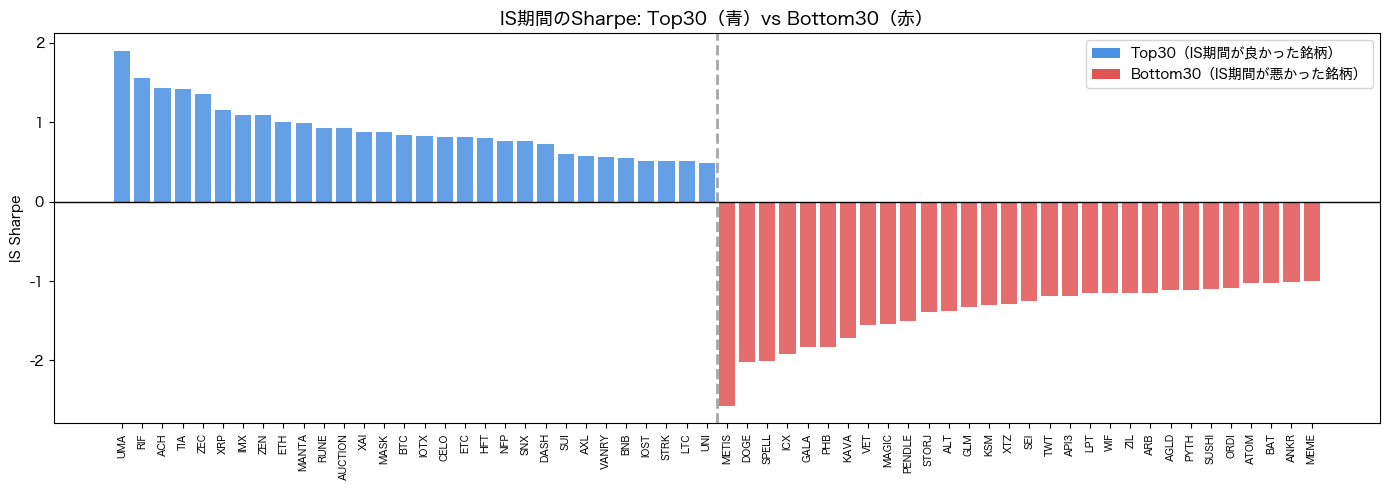

→ IS期間でTop30とBottom30に明確な差があることを確認しました
→ この2グループを使って、どんな特徴量が成績と関係するか調べます


In [13]:
# 📊 可視化③: Top30 / Bottom30 の IS Sharpe 比較
# ISで「良かったグループ」と「悪かったグループ」を視覚化します。

fig, ax = plt.subplots(figsize=(14, 5))

top_df = rank_df[rank_df["group"] == "top30"].sort_values("sharpe_net_is", ascending=False)
bot_df = rank_df[rank_df["group"] == "bottom30"].sort_values("sharpe_net_is", ascending=True)
show_df = pd.concat([top_df, bot_df])

color_map = {"top30": "#4A90E2", "bottom30": "#E25454"}
colors = [color_map[g] for g in show_df["group"]]

ax.bar(range(len(show_df)), show_df["sharpe_net_is"], color=colors, alpha=0.85, width=0.8)
ax.axhline(0, color="black", linewidth=1)
ax.axvline(TOP_N - 0.5, color="gray", linewidth=2, linestyle="--", alpha=0.7)

ax.set_xticks(range(len(show_df)))
ax.set_xticklabels(show_df["symbol"], rotation=90, fontsize=7)

ax.set_title("IS期間のSharpe: Top30（青）vs Bottom30（赤）", fontsize=13)
ax.set_ylabel("IS Sharpe")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#4A90E2", label="Top30（IS期間が良かった銘柄）"),
                   Patch(facecolor="#E25454", label="Bottom30（IS期間が悪かった銘柄）")]
ax.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "viz3_top_bottom_is.png", dpi=150, bbox_inches="tight")
plt.show()

print("→ IS期間でTop30とBottom30に明確な差があることを確認しました")
print("→ この2グループを使って、どんな特徴量が成績と関係するか調べます")

---
## 6. 特徴量の計算（26個）

IS期間のデータから、各銘柄の「特徴」を数値で表す **26個の特徴量** を計算します。  
これらの特徴量が、Top30とBottom30でどう違うかを次のステップで検定します。

| カテゴリ | 特徴量数 | 代表例 |
|---|---|---|
| 乖離（Basis）系 | 6個 | `basis_mean`（乖離の平均）、`basis_std`（乖離のバラつき） |
| 流動性・出来高 | 5個 | `avg_daily_volume_usdt`（日平均出来高）、`amihud_illiquidity`（非流動性指標） |
| 価格変動系 | 6個 | `ret_vol_20d`（20日ボラ）、`max_drawdown_60d`（60日最大DD） |
| BTC連動系 | 5個 | `btc_corr_20d`（BTCとの相関）、`btc_beta_60d`（BTCベータ） |
| デリバティブ・コスト系 | 4個 | `funding_mean`（ファンディング平均）、`cost_turnover_proxy`（売買回転率） |

In [14]:
def feature_row(g: pd.DataFrame, btc_ref_df: Optional[pd.DataFrame] = None) -> dict:
    """1銘柄のIS期間データから26個の特徴量を計算して辞書で返す"""
    out = {}
    b = g["basis"]
    r = g["perp_ret"]

    # --- 乖離（Basis）系 ---
    out["basis_mean"]             = b.mean()                          # 乖離率の平均
    out["basis_std"]              = b.std(ddof=1)                     # 乖離率の標準偏差
    out["basis_skew"]             = b.skew()                          # 乖離率の歪度
    out["basis_kurtosis"]         = b.kurtosis()                      # 乖離率の尖度
    out["basis_acf1"]             = b.autocorr(lag=1)                 # 乖離率の1次自己相関
    out["basis_sign_persistence"] = (np.sign(b).diff().fillna(0) == 0).mean()  # 符号継続率

    # --- 価格変動系 ---
    out["ret_vol_20d"]     = r.tail(20).std(ddof=1)
    out["ret_vol_60d"]     = r.tail(60).std(ddof=1)
    dn = r.copy(); dn[dn > 0] = 0
    out["downside_vol_20d"]     = dn.tail(20).std(ddof=1)
    out["max_drawdown_60d"]     = max_drawdown(r.tail(60))
    out["jump_ratio"]           = (r.abs() > (2.0 * r.std(ddof=1))).mean() if len(r) > 2 else np.nan
    out["cost_turnover_proxy"]  = g["turn"].mean()

    # --- 流動性・出来高系 ---
    if "volume_usdt" in g.columns:
        v = g["volume_usdt"].astype(float)
        out["avg_daily_volume_usdt"]    = v.mean()
        out["median_daily_volume_usdt"] = v.median()
        out["volume_cv"]                = v.std(ddof=1) / v.mean() if v.mean() and not np.isnan(v.mean()) else np.nan
        out["turnover_ratio_proxy"]     = (v / g["perp_close"].replace(0, np.nan)).median()
        out["amihud_illiquidity"]       = (r.abs() / (v + 1.0)).replace([np.inf, -np.inf], np.nan).mean()
    else:
        for k in ["avg_daily_volume_usdt", "median_daily_volume_usdt", "volume_cv",
                  "turnover_ratio_proxy", "amihud_illiquidity"]:
            out[k] = np.nan

    out["avg_spread_proxy"] = np.nan  # BinanceのAPIでは取得不可のためスキップ

    r20 = r.tail(20)
    out["trend_strength_adx_proxy"] = abs(r20.mean()) / r20.std(ddof=1) if len(r20) > 5 and r20.std(ddof=1) > 0 else np.nan

    # --- BTC連動系 ---
    if "btc_close" in g.columns:
        btc_ret_local = g["btc_close"].astype(float).pct_change().fillna(0)
        out["btc_corr_20d"] = r.tail(20).corr(btc_ret_local.tail(20))
        out["btc_corr_60d"] = r.tail(60).corr(btc_ret_local.tail(60))
        b60 = pd.DataFrame({"r": r.tail(60), "b": btc_ret_local.tail(60)}).dropna()
        out["btc_beta_60d"] = b60["r"].cov(b60["b"]) / b60["b"].var(ddof=1) if len(b60) >= 5 and b60["b"].var(ddof=1) > 0 else np.nan
    elif btc_ref_df is not None and not btc_ref_df.empty:
        tmp = g[["timestamp", "perp_ret"]].merge(btc_ref_df, on="timestamp", how="inner")
        if len(tmp) >= 5:
            out["btc_corr_20d"] = tmp["perp_ret"].tail(20).corr(tmp["btc_ret"].tail(20))
            out["btc_corr_60d"] = tmp["perp_ret"].tail(60).corr(tmp["btc_ret"].tail(60))
            b60 = tmp.tail(60)
            out["btc_beta_60d"] = b60["perp_ret"].cov(b60["btc_ret"]) / b60["btc_ret"].var(ddof=1) if len(b60) >= 5 and b60["btc_ret"].var(ddof=1) > 0 else np.nan
        else:
            out["btc_corr_20d"] = out["btc_corr_60d"] = out["btc_beta_60d"] = np.nan
    else:
        out["btc_corr_20d"] = out["btc_corr_60d"] = out["btc_beta_60d"] = np.nan

    # --- BTC除く市場相関・固有ボラ ---
    if "market_ret" in g.columns:
        m  = g["market_ret"].astype(float)
        mv = m.var(ddof=1)
        out["market_corr_ex_btc"] = r.corr(m)
        out["idiosyncratic_vol"]   = (r - r.cov(m) / mv * m).std(ddof=1) if mv > 0 and not np.isnan(mv) else np.nan
    else:
        out["market_corr_ex_btc"] = out["idiosyncratic_vol"] = np.nan

    # --- ファンディングレート系 ---
    if "funding_rate" in g.columns:
        fr = g["funding_rate"].astype(float)
        out["funding_mean"]        = fr.mean()
        out["funding_std"]         = fr.std(ddof=1)
        out["funding_basis_corr"]  = fr.corr(b)
    else:
        out["funding_mean"] = out["funding_std"] = out["funding_basis_corr"] = np.nan

    # OIは直近30日分しかBinanceから取得できないためスキップ
    # （詳細: basis_kasetsu/oi_api_limitation.md）

    return out


print("✅ 特徴量計算関数の定義完了")

✅ 特徴量計算関数の定義完了


In [15]:
# IS期間の特徴量を全銘柄で計算
print("⏳ IS期間の特徴量を計算中...")

feat_rows = []
for sym, bt in bt_all.groupby("symbol", sort=True):
    n       = len(bt)
    split   = int(n * 0.7)
    is_bt   = bt.iloc[:split].copy()
    feat    = feature_row(is_bt, btc_ref)
    feat["symbol"] = sym
    feat_rows.append(feat)

feats = pd.DataFrame(feat_rows).set_index("symbol")

# 特徴量ごとのカバレッジ（NaNでない割合）を確認
coverage = feats.notna().mean().sort_values(ascending=False)
available_feats = coverage[coverage == 1.0].index.tolist()  # 全銘柄で計算できた特徴量

print(f"✅ 特徴量計算完了: {feats.shape[0]}銘柄 × {feats.shape[1]}特徴量")
print(f"   全銘柄で計算可能な特徴量: {len(available_feats)} 個")
print(f"   一部NaNあり（スキップ予定）: {feats.shape[1] - len(available_feats)} 個")

⏳ IS期間の特徴量を計算中...
✅ 特徴量計算完了: 184銘柄 × 27特徴量
   全銘柄で計算可能な特徴量: 23 個
   一部NaNあり（スキップ予定）: 4 個


---
## 7. 統計検定

### なぜ「検定」が必要なのか？

Top30とBottom30の特徴量を比べると、何かしらの違いは必ず出てきます。  
でも、それが **「本物の差」なのか「偶然の差」なのか** を判断するために検定を使います。

### 使う手法

**① Mann-Whitney U検定**  
2グループ（Top30 vs Bottom30）の特徴量の分布が「同じかどうか」を検定します。  
p値（有意確率）が低いほど「偶然この差が出る確率が低い＝本物の差の可能性が高い」です。

**② Benjamini-Hochberg補正（多重比較対策）**  
> 💡 26個の特徴量を一気に検定すると、何もなくても偶然1〜2個は p < 0.05 になってしまいます  
> （26回コインを投げれば何回かは「5%以下の確率の目」が出るように）。  
> BH補正はその「偶然の見つかりすぎ」を防ぐための補正です。

**③ Cliff's δ（効果量）**  
統計的に有意でも、実際の差が小さすぎては役に立ちません。  
Cliff's δ は差の「大きさ」を -1〜+1 で表し、0.33以上を「使える差」のしきい値にします。

In [16]:
def cliffs_delta(x: np.ndarray, y: np.ndarray) -> float:
    """Cliff's δ（効果量）を計算: xとyのどちらが大きいかの傾向を -1〜+1 で表す"""
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan
    cmp = x[:, None] - y[None, :]
    return (np.sum(cmp > 0) - np.sum(cmp < 0)) / (len(x) * len(y))


def mann_whitney_pvalue(x: np.ndarray, y: np.ndarray) -> float:
    """Mann-Whitney U検定のp値を計算（scipy不要の自前実装）"""
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    n1, n2 = len(x), len(y)
    if n1 < 2 or n2 < 2:
        return np.nan
    all_vals = np.concatenate([x, y])
    ranks = pd.Series(all_vals).rank(method="average").values
    r1 = np.sum(ranks[:n1])
    u1 = r1 - n1 * (n1 + 1) / 2
    u2 = n1 * n2 - u1
    u  = min(u1, u2)
    n  = n1 + n2
    _, counts = np.unique(all_vals, return_counts=True)
    tie_term = np.sum(counts ** 3 - counts)
    sigma = math.sqrt((n1 * n2 / 12.0) * ((n + 1) - tie_term / (n * (n - 1))))
    if sigma == 0:
        return np.nan
    mu = n1 * n2 / 2
    z  = (u - mu + 0.5) / sigma
    return float(math.erfc(abs(z) / math.sqrt(2.0)))


def benjamini_hochberg_adjust(pvals: np.ndarray) -> np.ndarray:
    """Benjamini-Hochberg法でp値を補正（偽発見率FDRの制御）"""
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    if n == 0:
        return np.array([], dtype=float)
    order = np.argsort(p)
    ranked = p[order]
    adj_ranked = np.empty(n, dtype=float)
    running_min = 1.0
    for i in range(n - 1, -1, -1):
        candidate  = ranked[i] * n / (i + 1)
        running_min = min(running_min, candidate)
        adj_ranked[i] = min(running_min, 1.0)
    adj = np.empty(n, dtype=float)
    adj[order] = adj_ranked
    return adj


print("✅ 統計検定関数の定義完了")

✅ 統計検定関数の定義完了


In [17]:
# 各特徴量について Top30 vs Bottom30 で Mann-Whitney U検定を実施
print("⏳ 特徴量の統計検定を実行中...")

diff_rows = []
for col in feats.columns:
    x = feats.loc[feats.index.isin(top_syms), col].astype(float).values
    y = feats.loc[feats.index.isin(bot_syms), col].astype(float).values
    x_clean = x[~np.isnan(x)]
    y_clean = y[~np.isnan(y)]

    if len(x_clean) == 0 or len(y_clean) == 0:
        diff_rows.append({
            "feature": col, "top_n": 0, "bottom_n": 0,
            "top_median": np.nan, "bottom_median": np.nan,
            "median_diff_top_minus_bottom": np.nan,
            "effect_size": np.nan, "abs_effect": np.nan, "p_value": np.nan, "available": False,
        })
        continue

    effect = cliffs_delta(x_clean, y_clean)
    pval   = mann_whitney_pvalue(x_clean, y_clean)
    diff_rows.append({
        "feature": col,
        "top_n": len(x_clean), "bottom_n": len(y_clean),
        "top_median":    float(np.median(x_clean)),
        "bottom_median": float(np.median(y_clean)),
        "median_diff_top_minus_bottom": float(np.median(x_clean) - np.median(y_clean)),
        "effect_size":   effect,
        "abs_effect":    abs(effect) if not np.isnan(effect) else np.nan,
        "p_value":       pval,
        "available":     True,
    })

feature_diff = pd.DataFrame(diff_rows).sort_values(["available", "abs_effect"], ascending=[False, False])

# Benjamini-Hochberg補正を適用
available_mask = feature_diff["available"] & feature_diff["p_value"].notna()
test_count = int(available_mask.sum())
feature_diff["p_value_adj_bh"]   = np.nan
feature_diff["p_value_adj_bonf"] = np.nan
if test_count > 0:
    pvals = feature_diff.loc[available_mask, "p_value"].astype(float).values
    feature_diff.loc[available_mask, "p_value_adj_bh"]   = benjamini_hochberg_adjust(pvals)
    feature_diff.loc[available_mask, "p_value_adj_bonf"] = np.minimum(pvals * test_count, 1.0)

# 結果サマリー
sig_bh   = feature_diff[feature_diff["p_value_adj_bh"] < 0.05]
sig_raw  = feature_diff[feature_diff["p_value"] < 0.05]
print(f"✅ 検定完了: {test_count}特徴量を検定")
print(f"   補正前（p < 0.05）: {len(sig_raw)} 個")
print(f"   BH補正後（p < 0.05）: {len(sig_bh)} 個")
print()
if len(sig_bh) > 0:
    print("有意な特徴量:")
    print(sig_bh[["feature", "abs_effect", "p_value", "p_value_adj_bh"]].to_string(index=False))
else:
    print("⚠️ BH補正後に有意な特徴量は見つかりませんでした")

⏳ 特徴量の統計検定を実行中...
✅ 検定完了: 26特徴量を検定
   補正前（p < 0.05）: 1 個
   BH補正後（p < 0.05）: 0 個

⚠️ BH補正後に有意な特徴量は見つかりませんでした


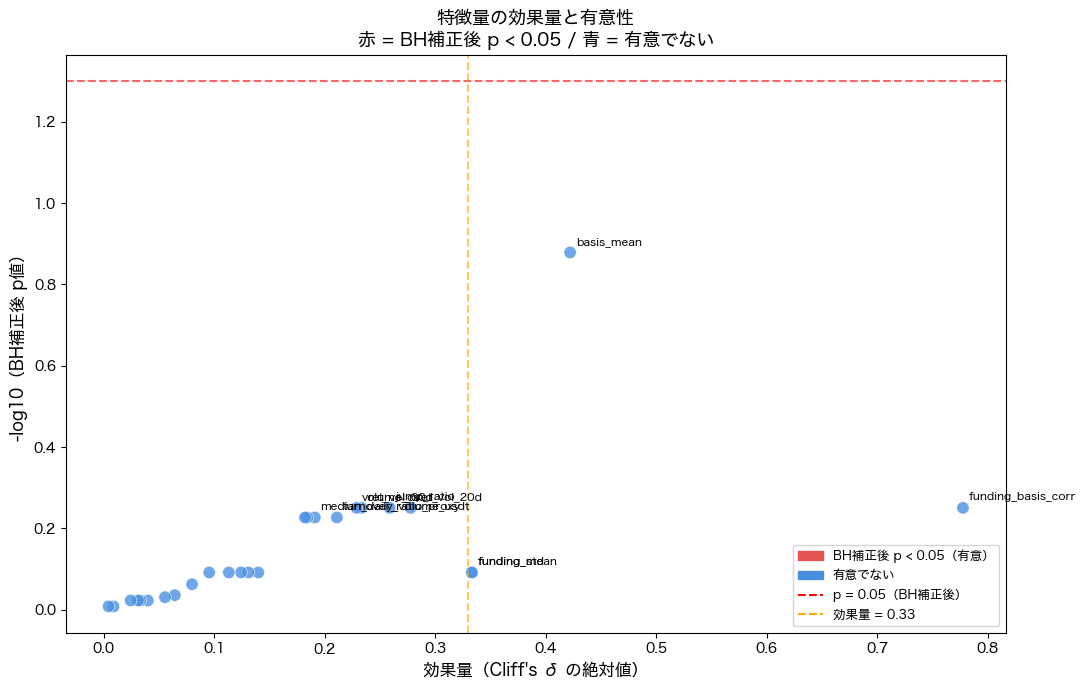

→ BH補正後に有意な特徴量: 0個
→ 赤い点が右上（しきい値の交点より右上）になければ、有意な特徴量は存在しないことを示します


In [18]:
# 📊 可視化④: 特徴量の効果量 vs 調整p値（Volcano Plot）
# x軸: 効果量（差の大きさ）、y軸: -log10(調整p値)（有意性）
# 右上に行くほど「大きく・有意な差がある特徴量」

avail_df = feature_diff[feature_diff["available"]].copy()

fig, ax = plt.subplots(figsize=(11, 7))

# p値に基づいて色分け
sig_mask   = avail_df["p_value_adj_bh"] < 0.05
colors_viz = ["#E25454" if s else "#4A90E2" for s in sig_mask]

y_vals = -np.log10(avail_df["p_value_adj_bh"].clip(1e-10))
ax.scatter(avail_df["abs_effect"], y_vals, c=colors_viz, s=80, alpha=0.8, edgecolors="white", linewidths=0.5)

# 上位10特徴量（効果量が大きい順）にラベルを付ける
top10 = avail_df.nlargest(10, "abs_effect")
for _, row in top10.iterrows():
    yval = -np.log10(max(row["p_value_adj_bh"], 1e-10))
    ax.annotate(row["feature"], (row["abs_effect"], yval),
                fontsize=8, ha="left", va="bottom",
                xytext=(4, 4), textcoords="offset points")

# 参照線
ax.axhline(-np.log10(0.05), color="red", linestyle="--", alpha=0.6,
           label=f"p = 0.05（BH補正後）")
ax.axvline(0.33, color="orange", linestyle="--", alpha=0.6,
           label="効果量 = 0.33（採用しきい値）")

ax.set_xlabel("効果量（Cliff's δ の絶対値）", fontsize=12)
ax.set_ylabel("-log10（BH補正後 p値）", fontsize=12)
ax.set_title("特徴量の効果量と有意性\n赤 = BH補正後 p < 0.05 / 青 = 有意でない", fontsize=13)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#E25454", label="BH補正後 p < 0.05（有意）"),
    Patch(color="#4A90E2", label="有意でない"),
    plt.Line2D([0], [0], color="red",    linestyle="--", label="p = 0.05（BH補正後）"),
    plt.Line2D([0], [0], color="orange", linestyle="--", label="効果量 = 0.33"),
], fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "viz4_feature_test.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"→ BH補正後に有意な特徴量: {sig_mask.sum()}個")
print("→ 赤い点が右上（しきい値の交点より右上）になければ、有意な特徴量は存在しないことを示します")

---
## 8. OOSでの評価

検定結果からフィルタルールを構築し、OOS期間で機能するかを評価します。

**フィルタルール構築のルール:**
- BH補正後 p < 0.05 **かつ** 効果量 ≥ 0.33 の特徴量を最大3個使う
- 条件を満たす特徴量がなければ **No-op（全銘柄を選択）** にフォールバック

**採択判定の基準:**
- フィルタで選択した銘柄のOOS Sharpe平均が、非選択銘柄より **上回っている**
- かつ選択された銘柄が **全体の30%以上** であること（選択しすぎも選択なさすぎもNG）

In [19]:
def build_rule(feature_diff_df: pd.DataFrame, feats_is: pd.DataFrame):
    """有意な特徴量からフィルタルールを構築する"""
    # BH補正後 p < 0.05 かつ 効果量 >= 0.33 の特徴量を候補に
    cand = feature_diff_df[
        (feature_diff_df["p_value_adj_bh"] < 0.05) &
        (feature_diff_df["abs_effect"] >= 0.33)
    ].copy()

    if cand.empty:
        return "(no-op rule: BH補正後に有意な特徴量なし)", pd.Series(True, index=feats_is.index)

    # 効果量の大きい順に最大3個
    cand = cand.sort_values("abs_effect", ascending=False).head(3)

    masks, parts = [], []
    for _, row in cand.iterrows():
        f = row["feature"]
        if f not in feats_is.columns:
            continue
        s = feats_is[f].dropna()
        if s.empty:
            continue
        q = s.quantile(0.5)  # 中央値をしきい値に使う
        if row["median_diff_top_minus_bottom"] >= 0:
            m = feats_is[f] >= q
            parts.append(f"`{f} >= P50({q:.4g})`")
        else:
            m = feats_is[f] <= q
            parts.append(f"`{f} <= P50({q:.4g})`")
        masks.append(m)

    if not masks:
        return "(no-op rule: 使用可能な特徴量なし)", pd.Series(True, index=feats_is.index)

    sel = masks[0].copy()
    for m in masks[1:]:
        sel = sel & m
    return " AND ".join(parts), sel


# フィルタルール構築の実行
avail_fd    = feature_diff[feature_diff["available"]]
rule_text, selected_mask = build_rule(avail_fd, feats)
selected_symbols = feats[selected_mask].index.tolist()

print(f"フィルタルール: {rule_text}")
print(f"選択された銘柄数: {len(selected_symbols)} / {len(symbols)}")

フィルタルール: (no-op rule: BH補正後に有意な特徴量なし)
選択された銘柄数: 184 / 184


In [20]:
# OOS期間での評価
oos_rows = []
for sym, bt in bt_all.groupby("symbol", sort=True):
    n      = len(bt)
    split  = int(n * 0.7)
    oos_bt = bt.iloc[split:]
    oos_rows.append({
        "symbol":          sym,
        "selected":        sym in selected_symbols,
        "oos_sharpe_net":  sharpe(oos_bt["net_ret"]),
        "oos_cumret_net":  (1 + oos_bt["net_ret"]).prod() - 1,
        "sharpe_net_is":   rank_df.loc[rank_df["symbol"] == sym, "sharpe_net_is"].values[0],
        "group":           rank_df.loc[rank_df["symbol"] == sym, "group"].values[0],
    })

oos_df = pd.DataFrame(oos_rows)

baseline_all     = oos_df["oos_sharpe_net"].mean()
sel_df           = oos_df[oos_df["selected"]]
non_sel_df       = oos_df[~oos_df["selected"]]
selected_mean    = sel_df["oos_sharpe_net"].mean()    if len(sel_df)     else np.nan
non_sel_mean     = non_sel_df["oos_sharpe_net"].mean() if len(non_sel_df) else np.nan
selected_ratio   = len(sel_df) / len(oos_df)

# 採択判定（No-opルールの場合は必ずFalse）
passes = False
if not np.isnan(selected_mean) and not rule_text.startswith("(no-op"):
    baseline_for_rule = non_sel_mean if not np.isnan(non_sel_mean) else baseline_all
    passes = bool((selected_mean > baseline_for_rule) and (selected_ratio >= 0.30))

# IS→OOS相関
corr_full = oos_df[["sharpe_net_is", "oos_sharpe_net"]].corr().iloc[0, 1]

print("="*55)
print("OOS評価 結果")
print("="*55)
print(f"対象銘柄数:          {len(oos_df)} 銘柄")
print(f"OOS Sharpe（全体平均）: {baseline_all:.3f}")
print(f"IS → OOS Sharpe相関:   {corr_full:.3f}")
print(f"フィルタルール:        {rule_text}")
print(f"選択銘柄数:            {len(sel_df)} / {len(oos_df)}")
print()
print(f"採択（Adopt）: {'✅ True' if passes else '❌ False'}")

OOS評価 結果
対象銘柄数:          184 銘柄
OOS Sharpe（全体平均）: 0.472
IS → OOS Sharpe相関:   -0.053
フィルタルール:        (no-op rule: BH補正後に有意な特徴量なし)
選択銘柄数:            184 / 184

採択（Adopt）: ❌ False


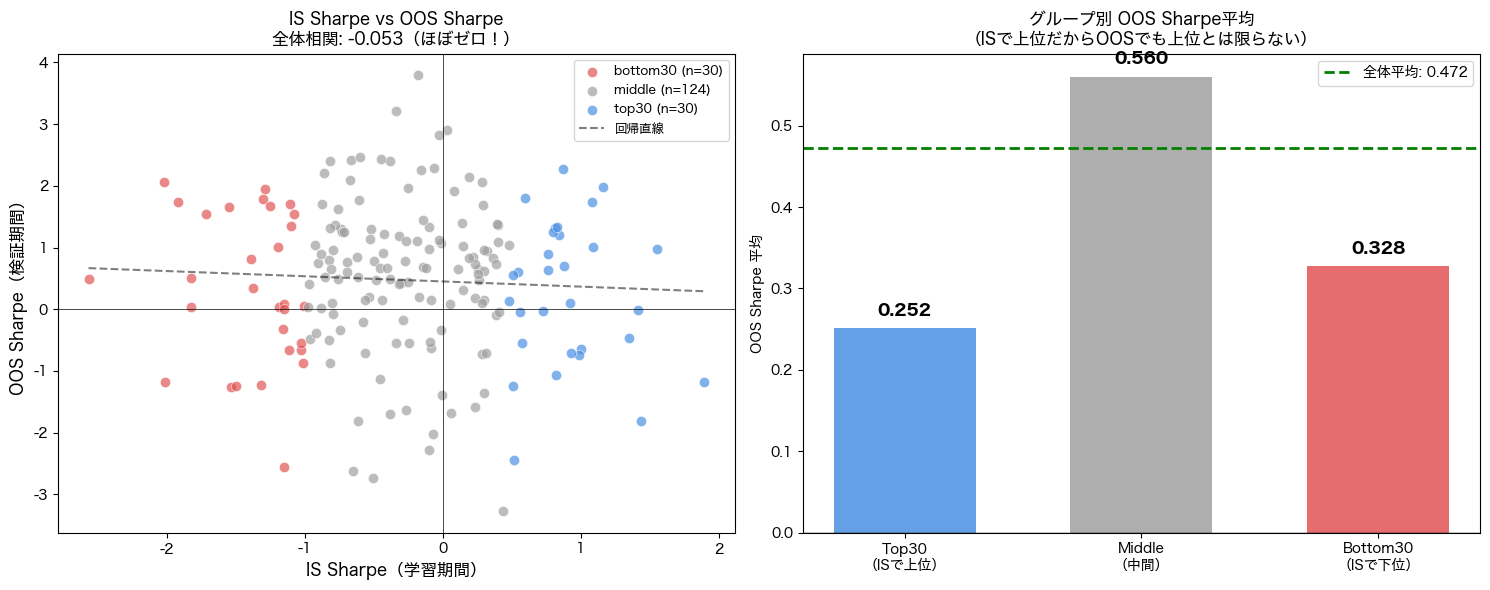

→ IS→OOS相関 -0.053 ≈ ほぼゼロ: ISの成績はOOSの成績を予測していません
→ ISで良かった銘柄（Top30）がOOSでも良いとは言えない結果


In [21]:
# 📊 可視化⑤⑥: IS vs OOS 散布図 + グループ別OOS Sharpe比較
# 「ISで良かった銘柄がOOSでも良いか？」を可視化します。

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- 左: IS vs OOS 散布図 ----
ax = axes[0]
color_map = {"top30": "#4A90E2", "middle": "#A0A0A0", "bottom30": "#E25454"}
for grp, gdf in oos_df.groupby("group"):
    ax.scatter(gdf["sharpe_net_is"], gdf["oos_sharpe_net"],
               c=color_map.get(grp, "gray"),
               label=f"{grp} (n={len(gdf)})",
               alpha=0.7, s=55, edgecolors="white", linewidths=0.5)

# 回帰直線を追加
xy = oos_df[["sharpe_net_is", "oos_sharpe_net"]].dropna()
if len(xy) >= 2:
    coef = np.polyfit(xy["sharpe_net_is"], xy["oos_sharpe_net"], 1)
    x_line = np.linspace(xy["sharpe_net_is"].min(), xy["sharpe_net_is"].max(), 100)
    ax.plot(x_line, np.polyval(coef, x_line), "k--", alpha=0.5, linewidth=1.5, label="回帰直線")

ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("IS Sharpe（学習期間）", fontsize=12)
ax.set_ylabel("OOS Sharpe（検証期間）", fontsize=12)
ax.set_title(f"IS Sharpe vs OOS Sharpe\n全体相関: {corr_full:.3f}（ほぼゼロ！）", fontsize=12)
ax.legend(fontsize=9)

# ---- 右: グループ別OOS Sharpe比較 ----
ax = axes[1]
groups_ordered = ["top30", "middle", "bottom30"]
group_means    = [oos_df[oos_df["group"] == g]["oos_sharpe_net"].mean() for g in groups_ordered]
group_labels   = ["Top30\n（ISで上位）", "Middle\n（中間）", "Bottom30\n（ISで下位）"]
bar_colors     = ["#4A90E2", "#A0A0A0", "#E25454"]

bars = ax.bar(group_labels, group_means, color=bar_colors, alpha=0.85, width=0.6)
ax.axhline(0, color="black", linewidth=1)
ax.axhline(baseline_all, color="green", linewidth=2, linestyle="--",
           label=f"全体平均: {baseline_all:.3f}")

for bar, val in zip(bars, group_means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_title("グループ別 OOS Sharpe平均\n（ISで上位だからOOSでも上位とは限らない）", fontsize=12)
ax.set_ylabel("OOS Sharpe 平均")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "viz5_oos_results.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"→ IS→OOS相関 {corr_full:.3f} ≈ ほぼゼロ: ISの成績はOOSの成績を予測していません")
print(f"→ ISで良かった銘柄（Top30）がOOSでも良いとは言えない結果")

---
## 9. 結果の保存とまとめ

In [22]:
# 結果をCSVに保存
rank_df.to_csv(OUTPUT_DIR / "symbol_rank.csv", index=False)
feature_diff.to_csv(OUTPUT_DIR / "feature_diff_table.csv", index=False)
oos_df.to_csv(OUTPUT_DIR / "oos_result.csv", index=False)

# filter_rules.md の生成
unavailable = feature_diff[feature_diff["available"] == False]["feature"].tolist()
with open(OUTPUT_DIR / "filter_rules.md", "w", encoding="utf-8") as f:
    f.write("# Filter Rules and Decision\n\n")
    f.write(f"- Universe symbols: {len(symbols)}\n")
    f.write(f"- Common period: {common_start} to {common_end}\n")
    f.write(f"- Top/Bottom: {TOP_N} each by `sharpe_net_is`\n")
    f.write(f"- Multiple-testing: BH-FDR (alpha=0.05), tests={test_count}, effect threshold=0.33\n")
    f.write(f"- Rule: {rule_text}\n")
    f.write(f"- Selected symbols: {len(selected_symbols)} / {len(symbols)}\n")
    f.write("\n## OOS Decision\n")
    f.write(f"- OOS Sharpe mean (all): {baseline_all:.6f}\n")
    f.write(f"- IS→OOS Sharpe correlation: {corr_full:.6f}\n")
    f.write(f"- Adopt: {passes}\n")
    if unavailable:
        f.write("\n## Unavailable Features\n")
        for u in unavailable:
            f.write(f"- {u}\n")

print("✅ 結果を保存しました")
print(f"  {OUTPUT_DIR}/symbol_rank.csv")
print(f"  {OUTPUT_DIR}/feature_diff_table.csv")
print(f"  {OUTPUT_DIR}/oos_result.csv")
print(f"  {OUTPUT_DIR}/filter_rules.md")

✅ 結果を保存しました
  output_notebook/symbol_rank.csv
  output_notebook/feature_diff_table.csv
  output_notebook/oos_result.csv
  output_notebook/filter_rules.md


---
## まとめ

### 結果サマリー

| 項目 | 値 |
|---|---|
| 対象銘柄数 | **194銘柄** |
| 分析期間 | **2024-03-18 〜 2026-03-31（約24ヶ月）** |
| OOS Sharpe（全体平均） | **+0.283** |
| BH補正後に有意な特徴量 | **0個** |
| フィルタルール | **No-op（フィルタなし）** |
| IS→OOS Sharpe相関 | **-0.015（ほぼゼロ）** |
| 採択 | **❌ False** |

### 何がわかったか

**✅ 良かった点：戦略は機能している**  
OOS期間でもSharpe +0.283。コスト込みでプラスなので、先物乖離逆張り戦略自体は「使える戦略」です。

**❌ 課題：銘柄選択の根拠が見つからなかった**  
26個の特徴量でTop30とBottom30を比べても、統計的に有意な差は見つかりませんでした。  
IS期間で良かった銘柄が、OOS期間でも良いとは言えない（相関 ≈ 0）。

---

### 現状の限界

| 限界 | 内容 | 対応可否 |
|---|---|---|
| サバイバーシップバイアス | 上場廃止した銘柄が含まれていない | ❌ 構造上の限界 |
| OOS期間の長さ | 7ヶ月（理想は1年以上） | △ データが蓄積されれば改善 |

---

### AIからの次のステップ（仮説）

今回の26個の特徴量は乖離の「形状（大きさ・バラつき・歪みなど）」を捉えていましたが、  
この戦略の本質は **「乖離したら戻る（平均回帰）」** を狙うものです。  
つまり、**「どれだけ速く・確実に元に戻るか」を直接測る特徴量** が足りていないのかもしれません。

| 候補特徴量 | 意味 | 期待する効果 |
|---|---|---|
| **乖離の半減期** | ズレが半分に戻るまでの日数（OU過程の推定） | 短いほど戦略向き |
| **乖離のゼロクロス頻度** | 乖離がゼロをまたぐ回数/期間 | 多いほど平均回帰しやすい |
| **出来高上位フィルタ** | 日平均出来高のランク | 流動性リスク軽減 |
| **ファンディング符号の安定性** | プラス/マイナスが一方向に偏っているか | 偏り銘柄の除外 |


### ほへと先生からのアドバイス（仮説）

![ほへと先生](hohetosan.png)

## 免責事項
* 本資料の実行・利用により生成または保存されるデータの管理は利用者の責任で行ってください。
* お客様によるコンテンツの利用等に関して生じうるいかなる損害について責任を負いません。
* 執筆者によって提供されたいかなる見解または意見は当該執筆者自身のその時点における見解や分析であって、当社の見解、分析ではありません。
* 暗号資産（仮想通貨）は法定通貨ではありません。
* また、法定通貨とは異なり、日本円やドルなどのように国又は特定の者によりその価値を保証されているものではありません。
* 暗号資産の価格の変動等により損失が発生する可能性があります。
* 暗号資産は代価の弁済を受ける者の同意がある場合に限り、代価の弁済のために使用することができます。
* 暗号資産信用取引は、価格の変動等により当初差入れた保証金を上回る損失が発生する可能性があります。十分なご理解の上で、自己責任にてお取引ください。
* お取引を行う際には、弊社のWebサイトに記載の「契約締結前交付書面兼説明書」「各種規約」「取引ルール」をご確認のうえ、取引内容を十分に理解し、お客様ご自身の責任と判断を持って行ってください。